IMPORT LIBRARIES

In [3]:
import plistlib
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import re
from matplotlib.lines import Line2D
from collections import defaultdict


LOAD THE MUSIC LIBRARY

In [4]:
with open('../docs/Library.xml', 'rb') as file:
    plist = plistlib.load(file)

CONVERT LIBRARY DATA INTO A DATAFRAME

In [5]:
tracks = plist['Tracks']
song_df = pd.DataFrame(tracks).T  # Transpose so each track is a row

FUNCTIONS

In [6]:
def ms_to_min(ms):
    """Convert milliseconds to mm:ss format."""
    
    if pd.isna(ms):
        return None
    seconds = ms / 1000
    minutes = seconds // 60
    rem_seconds = seconds % 60
    
    return f"{int(minutes)}:{int(rem_seconds):02d}"

def ms_to_hours(ms):
    """Convert milliseconds to a readable format with days, hours, etc."""
    
    if pd.isna(ms) or ms <= 0:
        return "0s"
    
    seconds = int(ms / 1000)
    
    years, rem = divmod(seconds, 31536000)   # 365 days
    months, rem = divmod(rem, 2592000)       # 30 days
    days, rem = divmod(rem, 86400)
    hours, rem = divmod(rem, 3600)
    minutes, rem = divmod(rem, 60)
    secs = rem
    
    parts = []
    if years:
        parts.append(f"{years}y")
    if months:
        parts.append(f"{months}mo")
    if days:
        parts.append(f"{days}d")
    if hours:
        parts.append(f"{hours}h")
    if minutes:
        parts.append(f"{minutes}m")
    if secs:
        parts.append(f"{secs}s")

    return ' '.join(parts)

def bytes_to_megabytes(bytes):
    """Convert bytes to megabytes."""
    
    if pd.isna(bytes):
        return None
    return round(bytes / (1024 * 1024), 2)

def get_quadrant(row, x_median, y_median):
    """Determine the quadrant based on play count and skip count."""
    
    if row['Play Count'] >= x_median and row['Skip Count'] >= y_median:
        return 'Popular but Skipped'
    elif row['Play Count'] >= x_median and row['Skip Count'] < y_median:
        return 'Favorites'
    elif row['Play Count'] < x_median and row['Skip Count'] >= y_median:
        return 'Ignored & Skipped'
    else:
        return 'Slow Burners'

def extract_all_artists(row):
    """Extract all artists from the 'Artist' and 'Name' fields."""
    
    # Handle artists with commas, ampersands, and 'and'
    exception_names = {
        'tyler, the creator': 'tyler_the_creator',
    }
    
    # Convert to lowercase for consistent matching
    artist_raw = str(row['Artist']).lower()
    name_raw = str(row['Name']).lower()
    
    # Replace exception names with tokens to protect them during splitting
    for original, token in exception_names.items():
        artist_raw = artist_raw.replace(original, token)
        name_raw = name_raw.replace(original, token)
    
    # If song has featured artists, extract them from the 'Name' field
    # Ex: "Portland feat. Quavo & Travis Scott" → ["Quavo", "Travis Scott"]
    feat_pattern = r"(feat\.|feat|featuring|ft\.)\s*(.+)"
    feat_artists = []
    
    match = re.search(feat_pattern, name_raw)
    if match:
        featured_part = match.group(2)
        feat_artists = re.split(r',|&| and ', featured_part) # Split by common delimiters: ',', '&', 'and'
    
    # Extract artists from the 'Artist' field
    main_artists = re.split(r',|&| and ', artist_raw)
    
    # Combine and clean
    all_artists = main_artists + feat_artists
    cleaned_artists = []
    for artist in all_artists:
        artist = artist.strip()
        artist = re.sub(r'[^\w\s\'\-&\$]', '', artist)    # Remove non-name punctuation like parentheses
        artist = re.sub(r'\s{2,}', ' ', artist)     # Collapse multiple spaces
        artist = artist.title()
        
        # Restore token to original name
        for original, token in exception_names.items():
            if token.title() == artist:
                artist = original.title()
        
        if artist:
            cleaned_artists.append(artist)
    
    return list(set(cleaned_artists))

CLEAN UP DATAFRAME

In [7]:
# Set 'Track ID' as index
song_df.set_index('Track ID', inplace=True)

# Drop irrelevant columns
song_df = song_df.drop(columns=['Kind', 'Disc Number', 'Disc Count', 'Date Modified', 'Bit Rate', 'Sample Rate', 'Play Date', 'Artwork Count', 'Sort Album', 'Sort Artist', 'Sort Name', 'Persistent ID', 'Track Type', 'Apple Music', 'Normalization', 'Loved', 'Sort Album Artist', 'Compilation', 'Stop Time', 'Clean', 'Sort Composer', 'Comments', 'Matched', 'Volume Adjustment', 'Album Loved', 'Playlist Only', 'Album Rating', 'Album Rating Computed', 'Rating', 'Location', 'File Folder Count', 'Library Folder Count', 'Grouping', ])

# Fill NaN values
song_df[['Explicit', 'Favorited', 'Part Of Gapless Album']] = song_df[['Explicit', 'Favorited', 'Part Of Gapless Album']].fillna(False)
song_df[['Skip Count', 'Play Count']] = song_df[['Skip Count', 'Play Count']].fillna(0)

# Convert data types
song_df['Play Count'] = song_df['Play Count'].astype(int)
song_df['Skip Count'] = song_df['Skip Count'].astype(int)
song_df['Explicit'] = song_df['Explicit'].astype(bool)
song_df['Favorited'] = song_df['Favorited'].astype(bool)
song_df['Part Of Gapless Album'] = song_df['Part Of Gapless Album'].astype(bool)

# Calculate total listening time
song_df['Listening Time (ms)'] = pd.to_numeric(song_df['Total Time']) * song_df['Play Count']
song_df['Listening Time'] = song_df['Listening Time (ms)'].apply(ms_to_hours)

# Convert 'Total Time' and 'Size' to a readable format
song_df['Total Time'] = pd.to_numeric(song_df['Total Time'])
song_df['Total Time'] = song_df['Total Time'].apply(ms_to_min)
song_df['Size'] = song_df['Size'].apply(bytes_to_megabytes)

# Rename columns for clarity
song_df.rename(columns={'Total Time': 'Time'}, inplace=True)
song_df.rename(columns={'Size': 'Size (MB)'}, inplace=True)
song_df.rename(columns={'Play Date UTC': 'Play Date'}, inplace=True)

# Convert date columns to datetime
song_df['Date Added'] = pd.to_datetime(song_df['Date Added'], errors='coerce')
song_df['Play Date'] = pd.to_datetime(song_df['Play Date'], errors='coerce').fillna(song_df['Date Added'])

# Add 'All Artists' column
song_df['All Artists'] = song_df.apply(extract_all_artists, axis=1)

/var/folders/rr/jdwhvnl573n1cmxbksk2ypgc0000gn/T/ipykernel_52623/2850825075.py:8: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  song_df[['Explicit', 'Favorited', 'Part Of Gapless Album']] = song_df[['Explicit', 'Favorited', 'Part Of Gapless Album']].fillna(False)
/var/folders/rr/jdwhvnl573n1cmxbksk2ypgc0000gn/T/ipykernel_52623/2850825075.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  song_df[['Skip Count', 'Play Count']] = song_df[['Skip Count', 'Play Count']].fillna(0)


In [8]:
# Create a column for all artists involved in a track
song_df['All Artists'] = song_df.apply(extract_all_artists, axis=1)

# Create a dict for counts
artist_totals = defaultdict(lambda: {'Play Count': 0, 'Skip Count': 0})

# Map total play and skip counts for each artist
for _, row in song_df.iterrows():
    for artist in row['All Artists']:
        artist_totals[artist]['Play Count'] += int(row['Play Count'] or 0)
        artist_totals[artist]['Skip Count'] += int(row['Skip Count'] or 0)

# Use a new variable name
artist_df = pd.DataFrame.from_dict(artist_totals, orient='index').astype(int)
artist_df.index.name = 'Artist'
artist_df = artist_df.sort_values(by='Artist', ascending=True)
artist_df

,Play Count,Skip Count
Artist,,
O,6,4
$,16,0
112,16,13
1Wayfrank,5,3
2 Chainz,369,114
...,...,...
Zichy,2,0
Zinoleesky,37,6
Zlatan,19,3


MAP GENRES TO BROADER CATEGORIES

In [9]:
genre_map = {
    'Rap': 'Hip-Hop/Rap',
    'Hip-Hop': 'Hip-Hop/Rap',
    'Gangsta Rap': 'Hip-Hop/Rap',
    'Alternative Rap': 'Hip-Hop/Rap',
    'Hip Hop/Rap': 'Hip-Hop/Rap',
    'Dirty South': 'Hip-Hop/Rap',
    'Hardcore Rap': 'Hip-Hop/Rap',
    'Hardcore': 'Hip-Hop/Rap',
    'Soul': 'R&B/Soul',
    'Electronic': 'EDM/Amapiano',
    'Electronica': 'EDM/Amapiano',
    'Dance': 'EDM/Amapiano',
    'Amapiano': 'EDM/Amapiano',
    'House': 'EDM/Amapiano',
    'Pop': 'Pop',
    'Alt. Rock': 'Alternative',
    'Indie Rock': 'Alternative',
    'Singer/Songwriter': 'Alternative',
    'Europe': 'Alternative',
    'Techno': 'Alternative',
    'Metal': 'Rock',
    'Hard Rock': 'Rock',
    'Worldwide': 'Afrobeats',
    'Afro-fusion': 'Afrobeats',
    'African': 'Afrobeats',
    'Alte': 'Afrobeats',
    'Afro-Beat': 'Afrobeats',
    'Afro-Pop': 'Afrobeats',
    'Reggae': 'Afrobeats',
    'Highlife': 'Afrobeats',
    'Urbano latino': 'Latin',
    'Indie Pop': 'Pop',
    'Soundtrack': 'Other',
    'New Wave': 'Other',
    'Holiday': 'Other',
    'TV Soundtrack': 'Other',
}

NORMALIZE GENRES AND GET PLAY COUNTS

In [10]:
# Create a new column for normalized genres
song_df['Normalized Genre'] = song_df['Genre'].map(genre_map).fillna(song_df['Genre'])
genre_counts = song_df.groupby('Normalized Genre')['Play Count'].sum().astype(int).sort_values(ascending=False)
song_df

,Name,Artist,Album Artist,Composer,Album,Genre,Size (MB),Time,Track Number,Track Count,...,Skip Count,Skip Date,Release Date,Explicit,Favorited,Part Of Gapless Album,Listening Time (ms),Listening Time,All Artists,Normalized Genre
Track ID,,,,,,,,,,,,,,,,,,,,,
2419,HUMBLE.,Kendrick Lamar,Kendrick Lamar,"Kendrick Lamar, A. Hogan, Michael L. Williams ...",DAMN.,Hip-Hop/Rap,6.09,2:57,8,14,...,6,2024-06-10 22:51:25,2017-03-31 07:00:00,True,False,False,3540000,59m,[Kendrick Lamar],Hip-Hop/Rap
2421,DNA.,Kendrick Lamar,Kendrick Lamar,K. Duckworth & M. Williams II,DAMN.,Hip-Hop/Rap,6.42,3:05,2,14,...,12,2024-03-03 16:15:35,2017-04-14 12:00:00,True,False,False,3532993,58m 52s,[Kendrick Lamar],Hip-Hop/Rap
2423,Mask Off,Future,Future,"Nayvadius Wilburn, Leland Wayne & Tommy Butler",FUTURE,Hip-Hop/Rap,6.97,3:24,7,20,...,4,2023-05-26 07:06:50,2017-02-17 08:00:00,True,False,False,3069000,51m 9s,[Future],Hip-Hop/Rap
2425,Congratulations (feat. Quavo),Post Malone,Post Malone,"Austin Post, Louis Bell, Adam Feeney, Quavious...",Stoney (Deluxe),Hip-Hop/Rap,7.49,3:40,12,18,...,9,2024-01-31 06:37:47,2016-11-04 07:00:00,True,True,False,7269405,2h 1m 9s,"[Quavo, Post Malone]",Hip-Hop/Rap
2427,Portland (feat. Quavo & Travis Scott),Drake,Drake,"Aubrey Drake Graham, Q. Marshall, J. Webster, ...",More Life,Hip-Hop/Rap,7.97,3:56,11,22,...,6,2024-02-09 19:03:43,2017-03-18 12:00:00,True,False,False,6151990,1h 42m 31s,"[Drake, Travis Scott, Quavo]",Hip-Hop/Rap
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22033,DUMBO,Travis Scott,JACKBOYS & Travis Scott,Jacques Webster II,JACKBOYS 2,Hip-Hop/Rap,8.15,3:58,5,20,...,0,NaN,2025-07-13 07:00:00,True,False,False,0,0s,[Travis Scott],Hip-Hop/Rap
22036,VELOUR,Don Toliver & Sheck Wes,JACKBOYS & Travis Scott,Caleb Toliver & Khadimou Fall,JACKBOYS 2,Hip-Hop/Rap,5.14,2:24,7,20,...,0,NaN,2025-07-13 07:00:00,True,False,False,0,0s,"[Sheck Wes, Don Toliver]",Hip-Hop/Rap
22039,CONTEST,Travis Scott & SoFaygo,JACKBOYS & Travis Scott,Jacques Webster II & Andre Dontrel Burt Jr.,JACKBOYS 2,Hip-Hop/Rap,9.27,4:32,8,20,...,0,NaN,2025-07-13 07:00:00,True,False,False,0,0s,"[Travis Scott, Sofaygo]",Hip-Hop/Rap


In [11]:
print("List of Available Styles : {}". format(plt.style.available))

List of Available Styles : ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


PLOT TOP GENRES BY PLAY COUNT

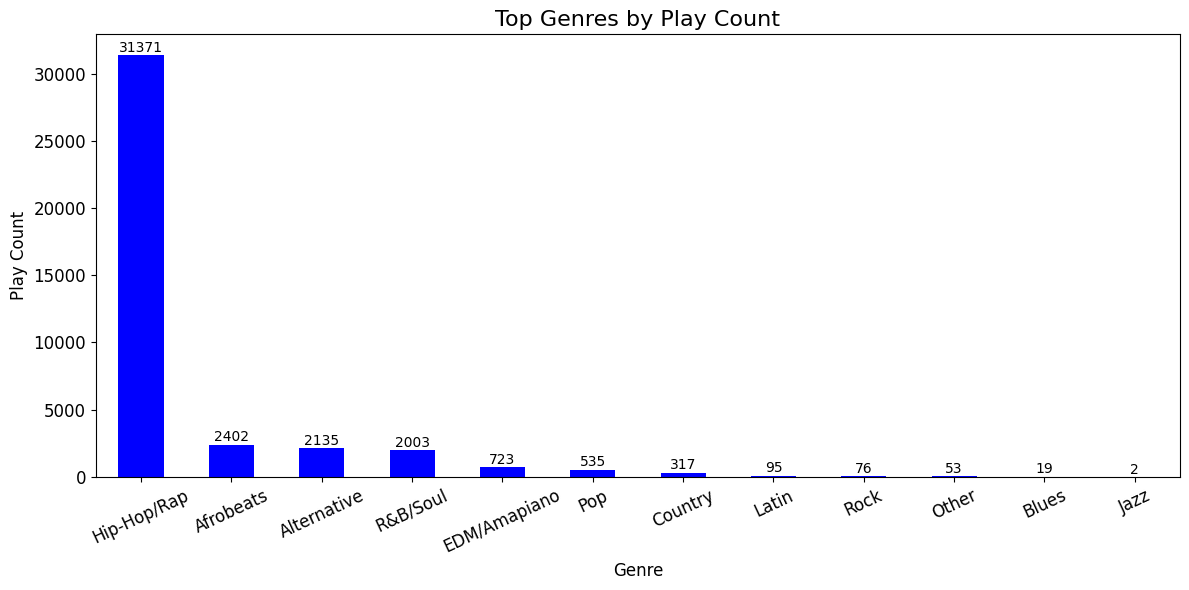

In [12]:
genre_counts.plot(kind='bar', figsize=(12,6), color='blue')
for i, value in enumerate(genre_counts):
    plt.text(i, value + 10, str(value), ha='center', va='bottom', fontsize=10)
plt.ylabel('Play Count', fontsize=12)
plt.xlabel('Genre', fontsize=12)
plt.xticks(rotation=25, fontsize=12)
plt.yticks(fontsize=12)
plt.title('Top Genres by Play Count', fontsize=16)
plt.tight_layout()

PLOT TOP 15 ARTISTS BY LISTENING TIME

In [13]:
artist_df

,Play Count,Skip Count
Artist,,
O,6,4
$,16,0
112,16,13
1Wayfrank,5,3
2 Chainz,369,114
...,...,...
Zichy,2,0
Zinoleesky,37,6
Zlatan,19,3


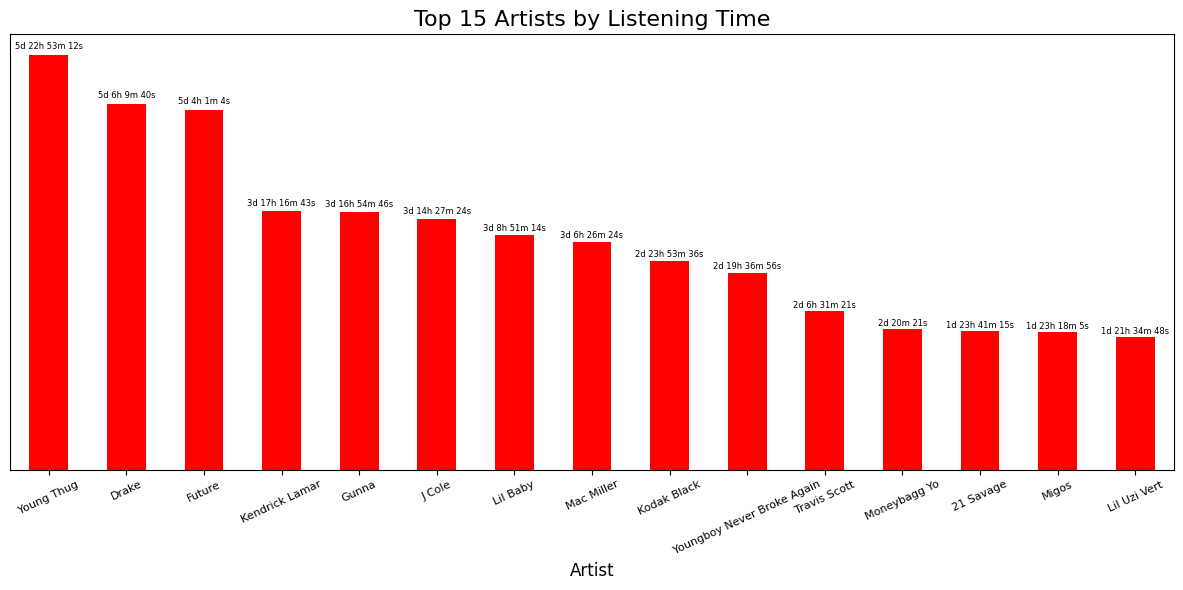

In [14]:
# Reset index to make 'Artist' a column
artist_df = artist_df.reset_index()

# Create a dict to hold artist listening time
artist_listening = defaultdict(int)

# Calculate total listening time for each artist
for _, row in song_df.iterrows():
    for artist in row['All Artists']:
        artist_listening[artist] += int(row['Listening Time (ms)'] or 0)

# Create a new column for artist total listening time
artist_df['Listening Time (ms)'] = artist_df['Artist'].map(artist_listening).fillna(0).astype(int)
artist_df['Listening Time'] = artist_df['Listening Time (ms)'].apply(ms_to_hours)

# Sort artists by total listening time and get the top 15
artists = artist_df.groupby('Artist')['Listening Time (ms)'].sum().sort_values(ascending=False)
artists = artists.head(15)

# Plot the top 15
artists.plot(kind='bar', figsize=(12,6), color='red')
for i, value in enumerate(artists):
    label = ms_to_hours(value)
    plt.text(i, value + value * 0.01, label, ha='center', va='bottom', fontsize=6)
plt.xlabel('Artist', fontsize=12)
plt.xticks(rotation=25, fontsize=8)
plt.yticks([])
plt.title('Top 15 Artists by Listening Time', fontsize=16)
plt.tight_layout()


In [15]:
artist_df

,Artist,Play Count,Skip Count,Listening Time (ms),Listening Time
0,O,6,4,1871022,31m 11s
1,$,16,0,1783648,29m 43s
2,112,16,13,5270832,1h 27m 50s
3,1Wayfrank,5,3,1131600,18m 51s
4,2 Chainz,369,114,88848996,1d 40m 48s
...,...,...,...,...,...
1050,Zichy,2,0,357430,5m 57s
1051,Zinoleesky,37,6,6543434,1h 49m 3s
1052,Zlatan,19,3,4138378,1h 8m 58s
1053,Zona Man,11,3,1750144,29m 10s


PLOT TOP 10 ALBUMS BY LISTENING TIME

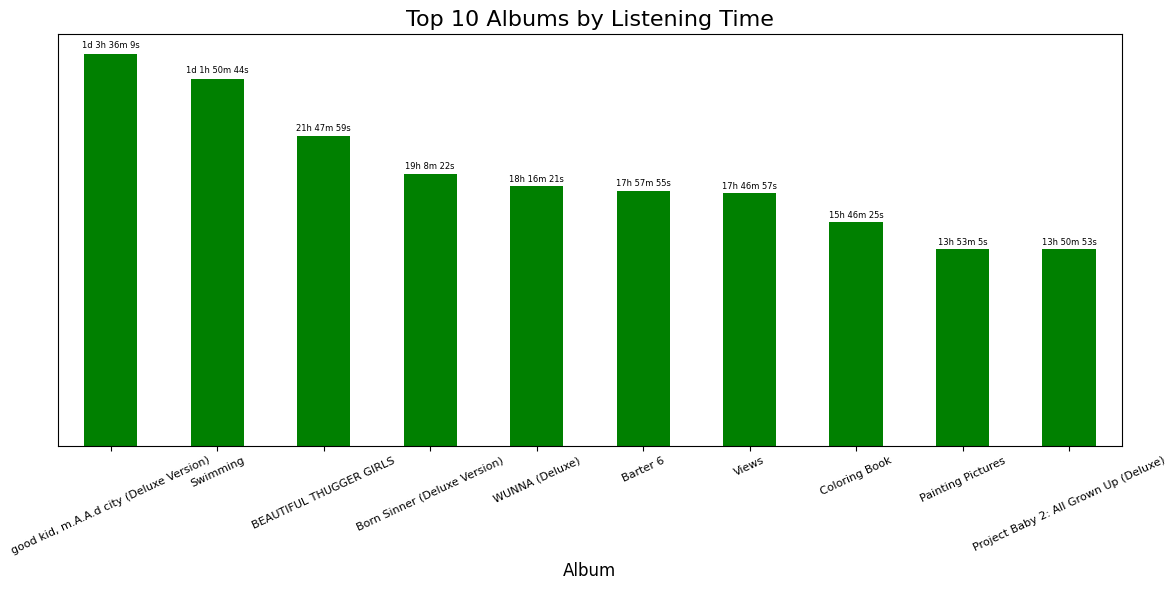

In [16]:
albums = song_df.groupby('Album')['Listening Time (ms)'].sum().sort_values(ascending=False)
albums = albums.head(10)

albums.plot(kind='bar', figsize=(12,6), color='green')
for i, value in enumerate(albums):
    label = ms_to_hours(value)
    plt.text(i, value + value * 0.01, label, ha='center', va='bottom', fontsize=6)
plt.xlabel('Album', fontsize=12)
plt.xticks(rotation=25, fontsize=8)
plt.yticks([])
plt.title('Top 10 Albums by Listening Time', fontsize=16)
plt.tight_layout()

PLOT TOP 10 SONGS BY SKIP COUNT

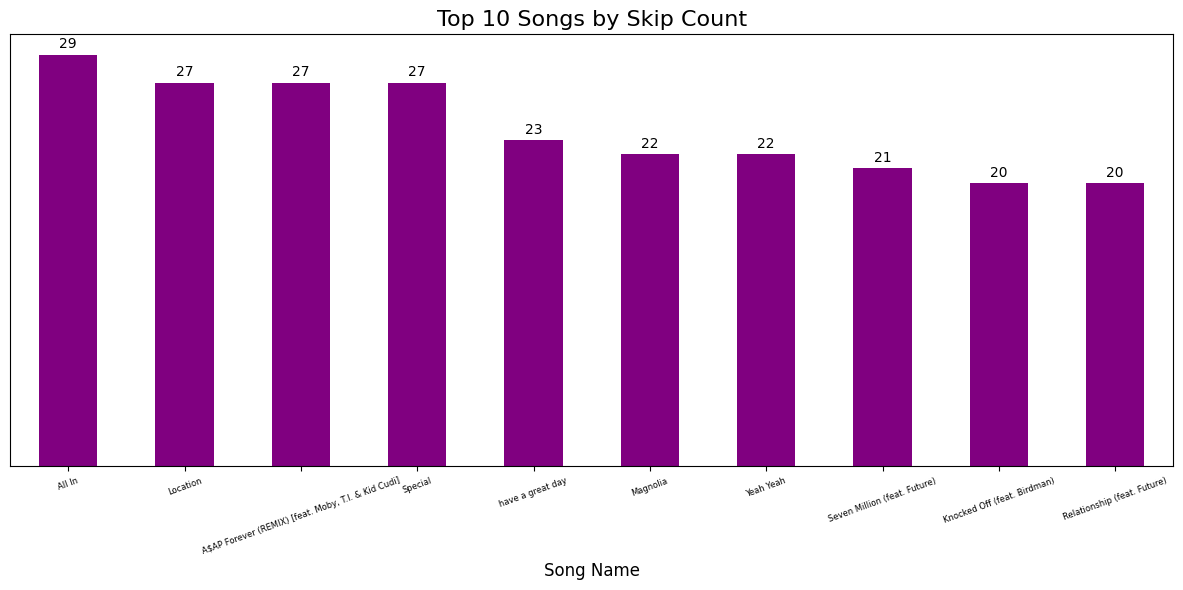

In [17]:
skips = song_df.groupby('Name')['Skip Count'].sum().astype(int).sort_values(ascending=False)
skips = skips.head(10)
skips.plot(kind='bar', figsize=(12,6), color='purple')
for i, value in enumerate(skips):
    label = str(value)
    plt.text(i, value + value * 0.01, label, ha='center', va='bottom', fontsize=10)
plt.xlabel('Song Name', fontsize=12)
plt.xticks(rotation=20, fontsize=6)
plt.yticks([])
plt.title('Top 10 Songs by Skip Count', fontsize=16)
plt.tight_layout()


PLOT PLAY VS SKIP COUNT BY ARTIST

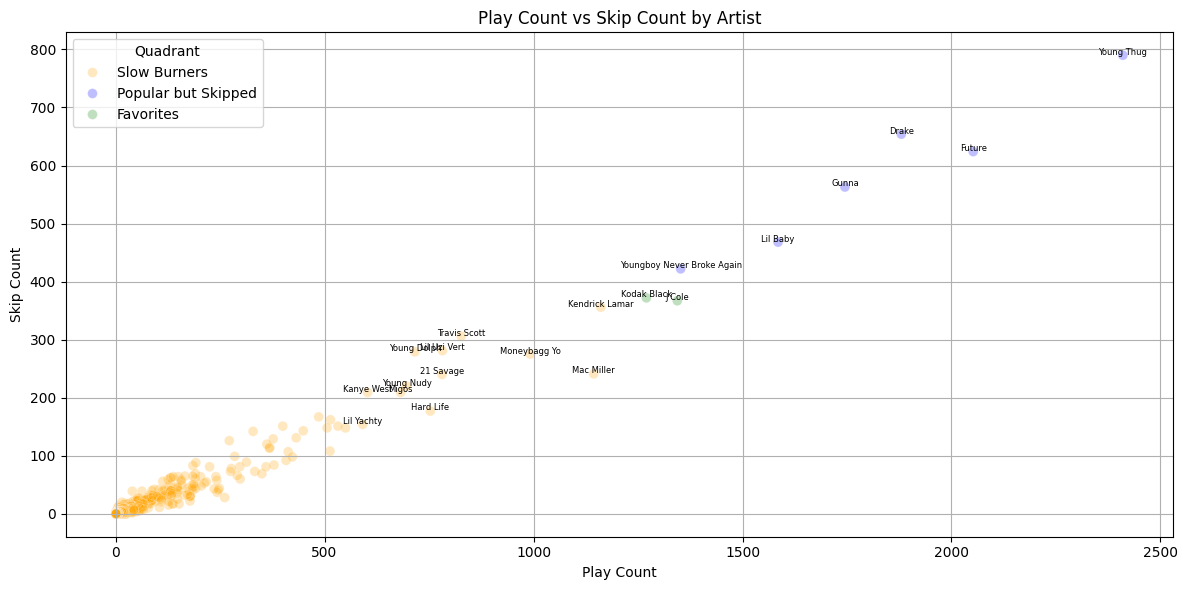

In [18]:
# Convert to DataFrame
artist_stats = pd.DataFrame.from_dict(artist_totals, orient='index').astype(int)
artist_stats.index.name = 'Artist'
artist_stats = artist_stats.reset_index()

# Filter out artists with no plays or skips
artist_stats = artist_stats[(artist_stats['Play Count'] > 0) | (artist_stats['Skip Count'] > 0)]

# Calculate midpoints for the axis
x_median = artist_stats['Play Count'].max() // 2
y_median = artist_stats['Skip Count'].max() // 2

# Assign quadrants based on play count and skip count
artist_stats['Quadrant'] = artist_stats.apply(lambda row: get_quadrant(row, x_median, y_median), axis=1)


plt.figure(figsize=(12, 6))

# Create a color palette for the quadrants
palette = {
    'Favorites': 'green',
    'Popular but Skipped': 'blue',
    'Ignored & Skipped': 'red',
    'Slow Burners': 'orange'
}

sns.scatterplot(data=artist_stats, x='Play Count', y='Skip Count', hue='Quadrant', palette=palette, alpha=0.25, s=50)

# Add labels for the top 20 artists
for artist, row in artist_stats.nlargest(20, 'Play Count').iterrows():
    plt.text(row['Play Count'], row['Skip Count'] + 1, row['Artist'], fontsize=6, ha='center')

plt.xlabel('Play Count')
plt.ylabel('Skip Count')
plt.title('Play Count vs Skip Count by Artist')
plt.legend(title='Quadrant')
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
artist_df

,Artist,Play Count,Skip Count,Listening Time (ms),Listening Time
0,O,6,4,1871022,31m 11s
1,$,16,0,1783648,29m 43s
2,112,16,13,5270832,1h 27m 50s
3,1Wayfrank,5,3,1131600,18m 51s
4,2 Chainz,369,114,88848996,1d 40m 48s
...,...,...,...,...,...
1050,Zichy,2,0,357430,5m 57s
1051,Zinoleesky,37,6,6543434,1h 49m 3s
1052,Zlatan,19,3,4138378,1h 8m 58s
1053,Zona Man,11,3,1750144,29m 10s


PLOT SONG COUNTS BY DECADE

<Axes: ylabel='count'>

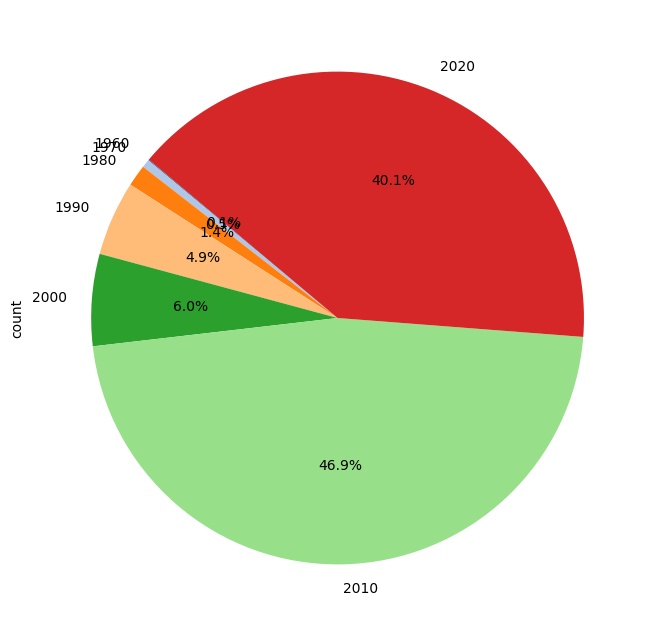

In [20]:
decade = song_df['Year'].apply(lambda x: (x // 10) * 10)
decade_counts = decade.value_counts().sort_index()
decade_counts.index = decade_counts.index.astype(int)
decade_counts.plot(kind='pie', figsize=(8, 8), autopct='%1.1f%%', startangle=140, colors=cm.tab20.colors)

/var/folders/rr/jdwhvnl573n1cmxbksk2ypgc0000gn/T/ipykernel_52623/3609488827.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_genres).colors  # 'tab20' gives 20 distinct colors
/var/folders/rr/jdwhvnl573n1cmxbksk2ypgc0000gn/T/ipykernel_52623/3609488827.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20', num_genres).colors


FileNotFoundError: [Errno 2] No such file or directory: 'charts/genre_trends.png'

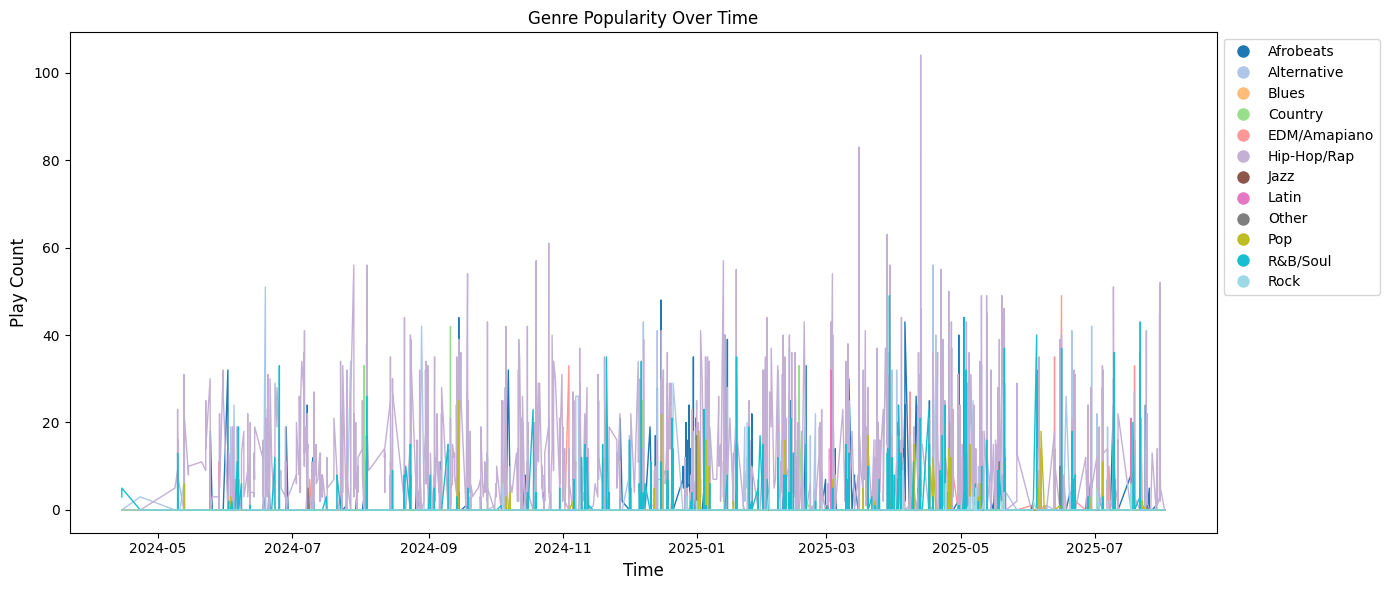

In [21]:
# Analyze genre trends over time

# Convert 'Play Date' to datetime and group by date and genre
song_df['Play Date'] = pd.to_datetime(song_df['Play Date'], errors='coerce')
genre_trends = song_df.groupby(['Play Date', 'Normalized Genre'])['Play Count'].sum().unstack().fillna(0)

# Get a list of N unique colors (one for each genre)
num_genres = genre_trends.shape[1]
colors = cm.get_cmap('tab20', num_genres).colors  # 'tab20' gives 20 distinct colors

# Setup
fig, ax = plt.subplots(figsize=(14, 6))
num_genres = genre_trends.shape[1]
colors = cm.get_cmap('tab20', num_genres).colors

# Plot clean lines with no markers
for i, genre in enumerate(genre_trends.columns):
    ax.plot(genre_trends.index, genre_trends[genre], color=colors[i], linewidth=1)

# Build custom legend with circles
legend_handles = [
    Line2D([0], [0], marker='o', color='w', label=genre,
           markerfacecolor=colors[i], markersize=10, linestyle='None')
    for i, genre in enumerate(genre_trends.columns)
]

# Add the legend
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1, 1))
ax.set_title('Genre Popularity Over Time')
plt.ylabel('Play Count', fontsize=12)
plt.xlabel('Time', fontsize=12)
plt.tight_layout()
plt.savefig('charts/genre_trends.png', bbox_inches='tight')
plt.show()

In [ ]:
# Save the cleaned DataFrame to a CSV file

song_df.to_csv('docs/library.csv', index=False)